In [39]:
import tiktoken

In [40]:
tokennizer = tiktoken.encoding_for_model("gpt-4o")

In [41]:
tokennizer= tiktoken.get_encoding("o200k_base")

In [42]:
print(tokennizer.name)

o200k_base


In [43]:
prompt = "vous etes un asssistant expert dans le domaine de l'analyse des snetiments"

In [44]:
tokens= tokennizer.encode(prompt)
print(tokens)
print(len(tokens))

[101896, 859, 268, 537, 472, 1087, 14055, 8333, 2671, 505, 46481, 334, 305, 187692, 731, 3967, 292, 15658]
18


In [45]:
for token in tokens:
    t=tokennizer.decode_single_token_bytes(token).decode("utf-8")
    print(t, end="/")

vous/ et/es/ un/ as/ss/istant/ expert/ dans/ le/ domaine/ de/ l/'analyse/ des/ sn/et/iments/

In [46]:
def tokens_count(prompt: str, model: str="o200k_base" ):
    tokennizer= tiktoken.get_encoding(model)
    return len(tokennizer.encode(prompt))

In [47]:
print(tokens_count(prompt="coucou cv"))

3


In [48]:
from langchain_openai import ChatOpenAI
from dotenv.ipython import load_dotenv

In [62]:
load_dotenv(override=True)

True

In [50]:
import os

In [52]:
llm= ChatOpenAI(model="gpt-4o", temperature=0)

In [53]:
resp=llm.invoke(input=[
    {"role":"system", "content": "you are a helpful assistant"},
    {"role":"user", "content": "c'est quoi un agent AI"}
])

In [54]:
from IPython.display import Markdown

In [55]:
print(display(Markdown(resp.content)))

Un agent AI (ou agent d'intelligence artificielle) est un programme informatique conçu pour percevoir son environnement, prendre des décisions et agir de manière autonome afin d'atteindre des objectifs spécifiques. Les agents AI peuvent être simples ou complexes, et ils sont utilisés dans une variété de domaines, allant des assistants virtuels comme Siri ou Alexa, aux systèmes de recommandation, aux robots autonomes, et bien plus encore.

Les agents AI fonctionnent généralement en suivant un cycle de perception-décision-action :

1. **Perception** : L'agent collecte des informations sur son environnement à travers des capteurs ou des données d'entrée. Cela peut inclure des données visuelles, sonores, textuelles, etc.

2. **Décision** : L'agent traite les informations perçues pour prendre des décisions. Cela peut impliquer l'utilisation d'algorithmes d'apprentissage automatique, de règles logiques, ou d'autres techniques d'intelligence artificielle pour déterminer la meilleure action à entreprendre.

3. **Action** : L'agent effectue une action basée sur sa décision. Cela peut être une action physique (comme déplacer un robot), une réponse verbale (comme répondre à une question), ou une autre forme d'interaction avec son environnement.

Les agents AI peuvent être conçus pour fonctionner dans des environnements statiques ou dynamiques, et ils peuvent être programmés pour apprendre et s'adapter à de nouvelles situations au fil du temps.

None


In [56]:
from langchain_ollama import ChatOllama

In [57]:
llm2= ChatOllama(model="qwen3.5:cloud")

In [58]:
resp=llm2.invoke(input=[
    {"role":"system", "content": "you are a helpful assistant"},
    {"role":"user", "content": "c'est quoi un agent AI"}
])

In [59]:
print(display(Markdown(resp.content)))

Un **agent AI** (ou agent intelligent) est un programme informatique capable de **percevoir son environnement, de prendre des décisions et d'agir de manière autonome** pour atteindre un objectif spécifique.

Pour faire simple : si une IA classique (comme un chatbot) est comme une **encyclopédie** qui répond à vos questions, un agent AI est comme un **stagiaire ou un assistant** qui peut exécuter des tâches pour vous.

Voici les points clés pour comprendre la différence et le fonctionnement :

### 1. La différence fondamentale : Action vs Réponse
*   **Modèle de langage (LLM) / Chatbot :** Vous lui posez une question, il vous répond avec du texte. Il est passif.
    *   *Exemple :* "Quelle est la météo à Paris ?" -> Il répond "Il fait 20 degrés."
*   **Agent AI :** Vous lui donnez un but, il utilise des outils pour l'atteindre. Il est actif.
    *   *Exemple :* "Réserve-moi un vol pour Paris s'il fait beau." -> Il vérifie la météo, cherche des vols sur un site, et propose une réservation.

### 2. Comment fonctionne un agent AI ?
Un agent fonctionne généralement en boucle (Perception -> Raisonnement -> Action) :

1.  **Perception :** Il reçoit une instruction ou observe des données (un email, un fichier, une demande utilisateur).
2.  **Raisonnement (Le "Cerveau") :** Il utilise un modèle de langage (LLM) pour analyser la demande et décider quoi faire. Il peut décomposer un gros problème en plusieurs petites étapes.
3.  **Action (Les "Outils") :** C'est ce qui le rend puissant. L'agent peut utiliser des outils externes :
    *   Naviguer sur le web.
    *   Exécuter du code.
    *   Envoyer un email.
    *   Interroger une base de données.
    *   Utiliser un logiciel (Excel, Slack, etc.).
4.  **Mémoire :** Il se souvient de ce qu'il a déjà fait pour ne pas tourner en rond et pour garder le contexte de la conversation.

### 3. Exemples concrets d'utilisation
*   **Voyage :** "Organise-moi un week-end à Rome avec un budget de 500€." L'agent cherche les hôtels, compare les vols, vérifie les disponibilités et crée un itinéraire.
*   **Développement informatique :** "Crée une page web simple avec un bouton rouge." L'agent écrit le code, le teste, corrige les erreurs et vous montre le résultat.
*   **Analyse de données :** "Analyse ce fichier Excel et dis-moi quelles sont les ventes du mois dernier." L'agent lit le fichier, fait les calculs et génère un graphique.
*   **Support client :** L'agent peut non seulement répondre au client, mais aussi procéder à un remboursement ou modifier une commande directement dans le système de l'entreprise.

### 4. Les niveaux d'autonomie
Tous les agents ne se valent pas :
*   **Copilote :** L'IA suggère des actions, mais l'humain doit valider chaque clic (ex: GitHub Copilot).
*   **Autonome :** L'IA exécute la tâche seule, mais l'humain définit l'objectif.
*   **Multi-agents :** Plusieurs agents spécialisés collaborent (un agent cherche l'info, un autre rédige, un troisième vérifie les faits).

### 5. Les défis actuels
Bien que prometteurs, les agents AI ont encore des limites :
*   **Fiabilité :** Ils peuvent faire des erreurs ou "halluciner" (inventer des faits).
*   **Boucles infinies :** Parfois, ils peuvent rester bloqués à essayer de résoudre un problème sans y arriver.
*   **Sécurité :** Donner à une IA le pouvoir d'agir (envoyer des emails, supprimer des fichiers) demande des garde-fous stricts pour éviter des actions dangereuses.

**En résumé :** Un agent AI est une IA à qui l'on a donné des **mains et des outils** pour agir sur le monde numérique, au-delà de la simple génération de texte.

None


In [60]:
from langchain_groq import ChatGroq

In [63]:
llm3 = ChatGroq(model="openai/gpt-oss-120b")

In [64]:
resp=llm3.invoke(input=[
    {"role":"system", "content": "you are a helpful assistant"},
    {"role":"user", "content": "c'est quoi un agent AI"}
])

In [65]:
print(display(Markdown(resp.content)))

**Un agent d’intelligence artificielle (IA) ** est un logiciel ou un système capable d’observer son environnement, de prendre des décisions et d’agir de façon autonome (ou semi‑autonome) afin d’atteindre un ou plusieurs objectifs définis.  

---

## 1. Principes de base

| Élément | Description |
|---|---|
| **Perception** | L’agent recueille des informations via des capteurs (texte, images, sons, données de capteurs physiques, etc.). |
| **Modélisation** | Il transforme ces données brutes en une représentation interne (ex. : état du monde, contexte). |
| **Décision / Planification** | À partir de cette représentation, il choisit une action en fonction d’une politique, d’un modèle de décision ou d’un algorithme d’optimisation. |
| **Action** | L’agent exécute l’action (envoi d’un message, mouvement d’un robot, mise à jour d’une base de données, etc.). |
| **Boucle de rétroaction** | Le résultat de l’action est à nouveau perçu, ce qui permet à l’agent d’ajuster son comportement (apprentissage ou adaptation). |

---

## 2. Types d’agents IA

| Catégorie | Exemple | Caractéristiques |
|---|---|---|
| **Agent réactif** | Chatbot simple qui répond à des mots‑clés. | Pas de mémoire du passé ; décision basée uniquement sur l’état actuel. |
| **Agent basé sur un modèle** | Système de navigation qui utilise une carte du terrain. | Connaît une représentation du monde (ex. : carte, dynamique). |
| **Agent objectif‑orienté** | Robot de livraison qui doit atteindre un point de dépôt. | Possède un but (fonction d’utilité) et cherche à le maximiser. |
| **Agent d’apprentissage (RL)** | Véhicule autonome qui apprend à conduire via le renforcement. | Ajuste sa politique en fonction de récompenses/punitions reçues. |
| **Agent multi‑agents** | Plateforme de trading où plusieurs bots interagissent. | Plusieurs agents qui coopèrent ou rivalisent, souvent avec communication. |

---

## 3. Comment l’agent « décide » ?

1. **Règles symboliques** (logique, systèmes experts) – décisions déterministes.  
2. **Modèles statistiques / ML** (réseaux de neurones, arbres de décision) – décisions probabilistes basées sur des données d’entraînement.  
3. **Apprentissage par renforcement** – l’agent apprend une fonction de valeur ou une politique qui maximise une récompense cumulative.  
4. **Planification** – recherche de séquences d’actions (ex. : A*, planification hiérarchique).  

---

## 4. Exemples concrets

| Domaine | Agent IA | Fonctionnement |
|---|---|---|
| **Assistants virtuels** (Siri, Alexa, ChatGPT) | Agent conversationnel | Analyse le texte/voix → comprend l’intention → génère une réponse ou exécute une commande. |
| **Véhicules autonomes** | Agent de conduite | Capteurs (LIDAR, caméras) → perception de la route → planification de trajectoire → contrôle du volant/accélérateur. |
| **Jeux vidéo** | NPC (personnage non‑joueur) | IA réactive ou basée sur RL pour se comporter de façon crédible (ex. : ennemis qui apprennent les stratégies du joueur). |
| **Robots industriels** | Agent de manipulation | Vision + planification de mouvement → saisie d’objets → adaptation aux variations. |
| **Systèmes de recommandation** | Agent de filtrage | Analyse le comportement de l’utilisateur → prédit les contenus susceptibles de plaire → propose des items. |

---

## 5. Différence entre **modèle IA** et **agent IA**

- **Modèle IA** : une fonction mathématique (ex. : un réseau de neurones) qui transforme des entrées en sorties. Il ne possède pas d’interaction continue avec le monde.
- **Agent IA** : intègre un ou plusieurs modèles **dans une boucle d’action‑perception‑apprentissage**. L’agent est « actif », il agit, reçoit du feedback et peut se ré‑entraîner.

---

## 6. Points d’attention et limites

| Problème | Conséquence | Mitigation |
|---|---|---|
| **Biais des données** | Décisions injustes ou inexactes. | Jeux de données diversifiés, audit de biais. |
| **Sécurité** | Actions imprévues (ex. : robot qui se coince). | Vérifications formelles, tests en environnement simulé. |
| **Transparence** | Difficulté à expliquer les décisions (boîte noire). | Méthodes d’interprétabilité (SHAP, LIME). |
| **Éthique** | Impact sur l’emploi, vie privée. | Cadres de gouvernance, consentement éclairé. |

---

## 7. Ressources pour aller plus loin

- **Livres** : *Artificial Intelligence: A Modern Approach* (Russell & Norvig) – chapitres sur agents.  
- **Cours en ligne** : Coursera – *Reinforcement Learning* (University of Alberta).  
- **Bibliothèques** : OpenAI Gym (environnements de RL), ROS (robotique), LangChain (agents conversationnels).  
- **Articles** : “Agent‑Based Modeling and Simulation” (Springer) – pour les systèmes multi‑agents.

---

### Résumé

Un **agent IA** est un système autonome qui perçoit son environnement, prend des décisions (souvent à l’aide de modèles d’apprentissage) et agit pour atteindre des objectifs. Selon le degré de complexité (réactif, basé sur un modèle, objectif‑orienté, apprenant), les agents peuvent être utilisés dans des chatbots, des robots, des véhicules autonomes, des jeux vidéo, des systèmes de recommandation, etc. Leur puissance réside dans la boucle continue de perception‑décision‑action, qui les différencie d’un simple modèle statique.

None


In [66]:
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools= llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
])

In [69]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [70]:
resp = llm_with_tools.invoke(input=[
    SystemMessage(""),
    HumanMessage("génère une image d'un oiseau callopsite sur la main d'une jeune fille et qui sont heureux"),
])

In [71]:
from IPython.display import Image
import base64

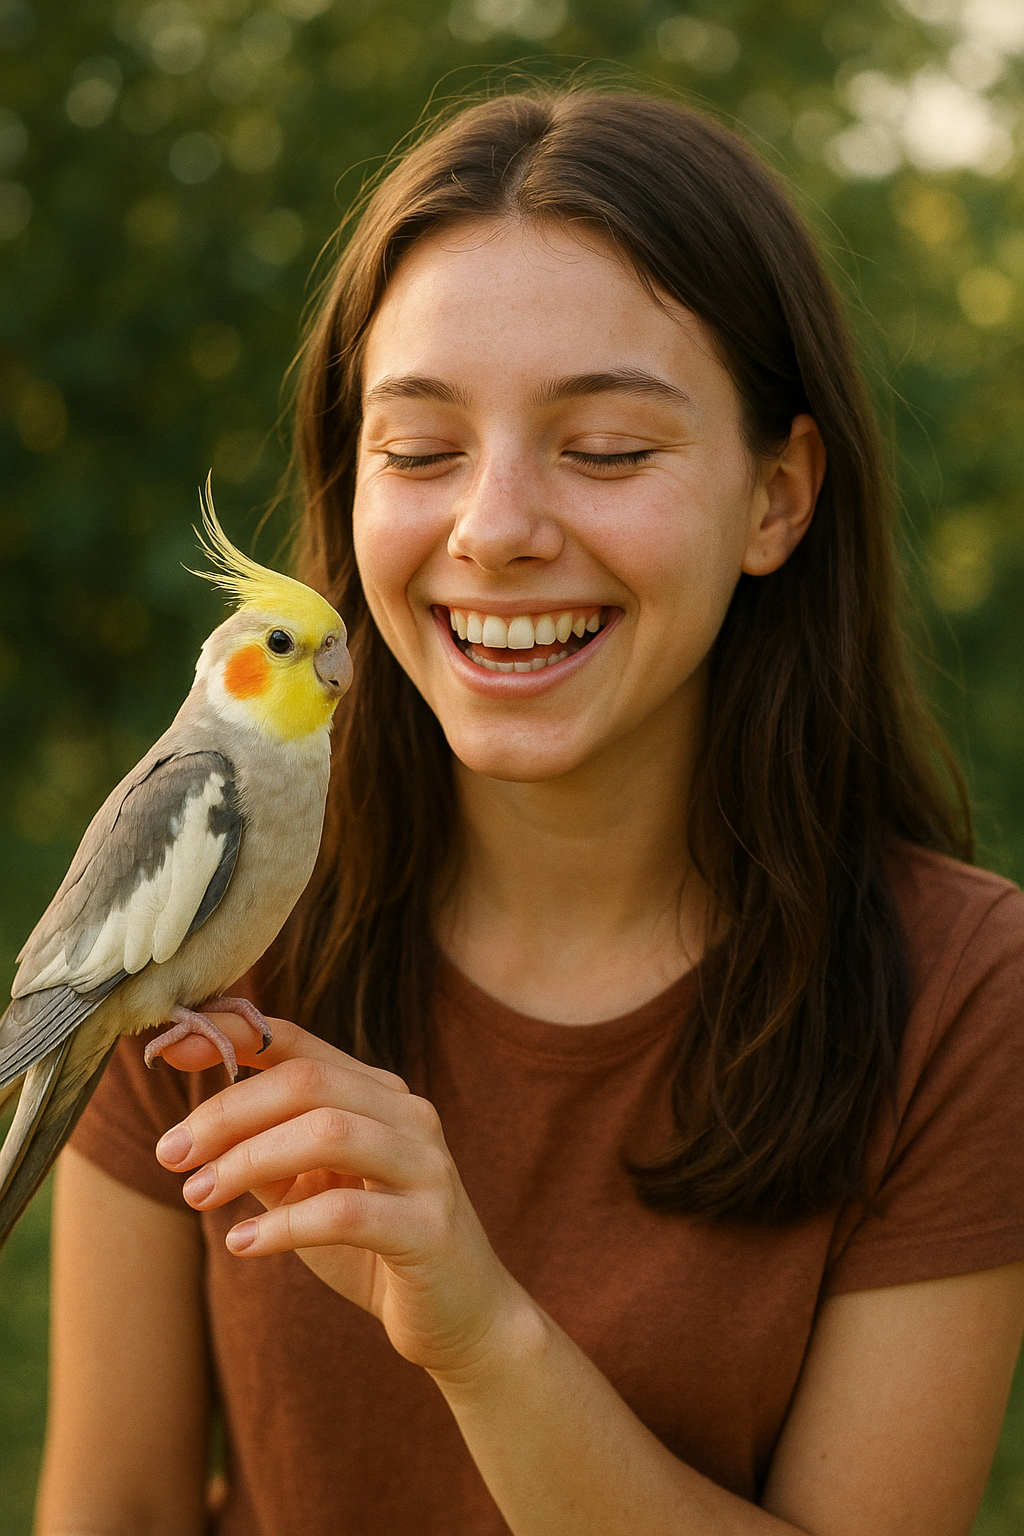

In [73]:
Image(base64.b64decode(resp.content_blocks[0]['base64']))

In [74]:
path="r.png"

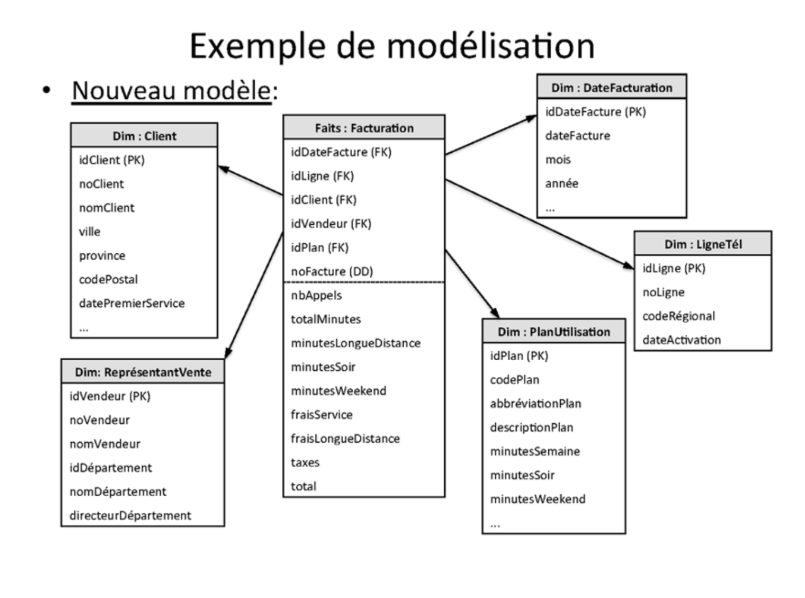

In [75]:
Image(path)

In [76]:
llm5= ChatOpenAI(model="gpt-5.2")

In [77]:
with open(path, "rb") as file:
    img= base64.b64encode(file.read()).decode("utf-8")

In [78]:
resp = llm5.invoke(input=[
    HumanMessage(content=[
     {"type": "text", "text": "explique ce qu'il y a dans cette image"},
     {"type": "image_url", "image_url":{"url":f"data:image/png;base64,{img}"}}
    ])
])


In [79]:
print(display(Markdown(resp.content)))

L’image montre un **exemple de modélisation de type “schéma en étoile”** (data warehouse / BI) pour analyser la **facturation** (probablement télécom).

### 1) La table centrale : **Faits : Facturation**
Au centre, la table de faits contient :
- des **clés étrangères (FK)** vers les dimensions :  
  `idDateFacture`, `idLigne`, `idClient`, `idVendeur`, `idPlan`
- un identifiant de document : `noFacture (DD)` (numéro de facture)
- des **mesures** (valeurs à analyser) :  
  `nbAppels`, `totalMinutes`, `minutesLongueDistance`, `minutesSoir`, `minutesWeekend`, `fraisService`, `fraisLongueDistance`, `taxes`, `total`, etc.

L’idée : cette table enregistre des montants/quantités (minutes, frais, taxes…) et pointe vers le “contexte” via les dimensions.

### 2) Les dimensions autour (les “axes d’analyse”)

**Dim : Client**
- infos sur le client : `noClient`, `nomClient`, `ville`, `province`, `codePostal`, `datePremierService`, …

**Dim : ReprésentantVente**
- infos sur le vendeur : `noVendeur`, `nomVendeur`, `idDepartement`, `nomDépartement`, `directeurDépartement`, …

**Dim : DateFacturation**
- infos de calendrier : `dateFacture`, `mois`, `année`, …

**Dim : LigneTél**
- infos sur la ligne téléphonique : `noLigne`, `codeRégional`, `dateActivation`, …

**Dim : PlanUtilisation**
- infos sur le plan/forfait : `codePlan`, `abréviationPlan`, `descriptionPlan`, minutes incluses (semaine/soir/weekend), …

### 3) Ce que signifient les flèches
Les flèches représentent les **relations** : la table **Faits : Facturation** référence chaque dimension via une clé (FK).  
On peut ainsi analyser, par exemple :
- le **total** par **mois/année**
- les **minutes** par **plan**
- les **taxes/frais** par **client**, **ville**, ou **vendeur**
- l’usage par **ligne téléphonique** ou **code régional**

En résumé : c’est un modèle décisionnel où **Facturation** est la table de mesures, et les tables **Dim** décrivent les angles d’analyse.

None


In [80]:
system_message="""
Voues etes un expert dans l'analyse de sentiments sur les avis de PC.
Effectuer une analyse de sentiments sur les avis de PC consiste à examiner les opinions exprimées par les utilisateurs afin d’identifier leur perception des différents aspects du produit, notamment l’écran, le stockage et le clavier. Cette analyse permet de déterminer si les commentaires sont positifs, négatifs ou neutres pour chaque composant, en s’appuyant sur les mots et expressions utilisés dans les avis. Par exemple, un écran décrit comme « lumineux et net » reflète un sentiment positif, tandis qu’un stockage jugé « insuffisant » indique un sentiment négatif. En synthétisant ces informations, il devient possible d’obtenir une vision globale de la satisfaction des utilisateurs et d’identifier les points forts et les points à améliorer du PC.
"""

In [81]:
llm6 = ChatOpenAI(model="gpt-5.2")

In [82]:
resp = llm6.invoke(input=[
    SystemMessage(system_message),
    HumanMessage("analyse les sentiments de ces avis de PC: \n1. l'écran est lumineux et net, le stockage est insuffisant et le clavier est confortable\n2. l'écran est sombre et flou, le stockage est suffisant et le clavier est inconfortable\n3. l'écran est lumineux et net, le stockage est suffisant et le clavier est confortable")
])

In [83]:
print(resp.content)

### Analyse de sentiments par avis (écran / stockage / clavier)

| Avis | Écran | Stockage | Clavier | Synthèse globale |
|---|---|---|---|---|
| 1 | **Positif** (« lumineux et net ») | **Négatif** (« insuffisant ») | **Positif** (« confortable ») | Globalement **plutôt positif**, mais gros point faible : stockage |
| 2 | **Négatif** (« sombre et flou ») | **Positif** (« suffisant ») | **Négatif** (« inconfortable ») | Globalement **négatif** (écran et clavier critiqués) |
| 3 | **Positif** (« lumineux et net ») | **Positif** (« suffisant ») | **Positif** (« confortable ») | Globalement **très positif** |

### Synthèse par composant (sur les 3 avis)
- **Écran** : 2 positifs, 1 négatif → sentiment **majoritairement positif**
- **Stockage** : 2 positifs, 1 négatif → sentiment **plutôt positif**
- **Clavier** : 2 positifs, 1 négatif → sentiment **majoritairement positif**

### Points clés
- **Point fort récurrent** : écran « lumineux et net » + clavier « confortable » (dans 2 avis sur 3).

In [84]:
import json